# Pathology Embedding Analysis (VAE vs Contrastive VAE)

This notebook compares embeddings of **healthy** vs **pathological** gaits
(e.g., Parkinson, neuropathy) using the trained VAE and Contrastive VAE.

Goals:
- Load trained VAE & Contrastive VAE
- Load healthy CASIA-B samples + new pathological samples
- Compute embeddings for all samples
- Visualize embedding space by condition
- Train simple classifiers:
  - Healthy vs Any Pathology (binary anomaly)
  - Multi-class conditions (normal, Parkinson, neuropathy, …)

In [1]:
# Setup and imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# Deep learning
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

# Computer vision
from PIL import Image

# Dimensionality reduction and visualization
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Add model paths
sys.path.append(str(Path('gait/models/vae').resolve()))
sys.path.append(str(Path('gait/preprocessing').resolve()))

Using device: cuda
PyTorch version: 2.5.1+cu121


In [2]:
from gait.models.vae.model import create_vae
from gait.models.vae.contrastive_model import create_contrastive_vae

# Paths to checkpoints – adjust if different
VAE_CHECKPOINT = Path('gait/models/best_model_vae.pth')
CONTRASTIVE_CHECKPOINT = Path('gait/models/vae/checkpoints_contrastive/best_model.pth')

print("Loading VAE...")
vae = create_vae(latent_dim=128)
if VAE_CHECKPOINT.exists():
    ckpt = torch.load(VAE_CHECKPOINT, map_location=device)
    vae.load_state_dict(ckpt['model_state_dict'])
    vae = vae.to(device)
    vae.eval()
    print(f"✅ VAE loaded (Epoch: {ckpt.get('epoch', 'N/A')})")
else:
    print(f"⚠️ VAE checkpoint not found at {VAE_CHECKPOINT}")

print("\nLoading Contrastive VAE...")
contrastive_vae = create_contrastive_vae(latent_dim=128, projection_dim=128)
if CONTRASTIVE_CHECKPOINT.exists():
    ckpt_c = torch.load(CONTRASTIVE_CHECKPOINT, map_location=device)
    contrastive_vae.load_state_dict(ckpt_c['model_state_dict'])
    contrastive_vae = contrastive_vae.to(device)
    contrastive_vae.eval()
    print(f"✅ Contrastive VAE loaded (Epoch: {ckpt_c.get('epoch', 'N/A')})")
    print(f"   Val Total Loss: {ckpt_c.get('val_total_loss', 'N/A')}")
    print(f"   Val Contrastive Loss: {ckpt_c.get('val_contrastive_loss', 'N/A')}")
else:
    print(f"⚠️ Contrastive VAE checkpoint not found at {CONTRASTIVE_CHECKPOINT}")

Loading VAE...
✅ VAE loaded (Epoch: 49)

Loading Contrastive VAE...
✅ Contrastive VAE loaded (Epoch: 49)
   Val Total Loss: 27.14780040516573
   Val Contrastive Loss: 5.230774751551011


In [3]:
def load_and_preprocess_image(image_path, target_size=(128, 64)):
    """
    Load GEI-like image (PNG/JPG) and convert to tensor (1, 1, 128, 64) in [0,1].
    """
    img = Image.open(image_path).convert('L')  # grayscale
    img = img.resize(target_size, Image.LANCZOS)
    arr = np.array(img, dtype=np.float32) / 255.0
    # (1, 1, H, W)
    return torch.from_numpy(arr).unsqueeze(0).unsqueeze(0)


def extract_embeddings_from_paths(model, image_paths, model_type='vae', use_projection=False):
    """
    Compute embeddings for a list of image paths using given model.
    Returns: np.array of shape (N, embedding_dim)
    """
    embeddings_list = []
    model.eval()
    with torch.no_grad():
        for p in image_paths:
            x = load_and_preprocess_image(p).to(device)  # (1,1,128,64)
            if model_type == 'vae':
                mu, _ = model.encode(x)
                emb = mu
            elif model_type == 'contrastive':
                if use_projection:
                    proj, _, _ = model.get_projection(x)
                    emb = proj
                else:
                    emb = model.get_embedding(x)
            else:
                raise ValueError(f"Unknown model type: {model_type}")
            embeddings_list.append(emb.cpu().numpy())
    if not embeddings_list:
        return np.empty((0, 128), dtype=np.float32)
    return np.concatenate(embeddings_list, axis=0)

In [4]:
from pathlib import Path

CASIA_IMAGES_ROOT = Path('Casia-B-Images/output')  # adjust if needed

def collect_casia_samples(images_root, max_subjects=50, max_images_per_subject=20):
    samples = {
        'paths': [],
        'subjects': [],
        'conditions': [],  # 'normal' for CASIA-B
    }
    images_root = Path(images_root)
    if not images_root.exists():
        print(f"⚠️ CASIA images not found at {images_root}")
        return samples
    
    subject_dirs = sorted([d for d in images_root.iterdir() if d.is_dir()])[:max_subjects]
    for subj_dir in subject_dirs:
        subj_id = subj_dir.name
        # Take a few images from each subject
        img_files = sorted(list(subj_dir.rglob('*.png')))[:max_images_per_subject]
        for img_path in img_files:
            samples['paths'].append(img_path)
            samples['subjects'].append(subj_id)
            samples['conditions'].append('normal')  # healthy baseline
    
    print(f"📸 CASIA: {len(samples['paths'])} images, {len(set(samples['subjects']))} subjects")
    return samples

healthy_samples = collect_casia_samples(CASIA_IMAGES_ROOT, max_subjects=50, max_images_per_subject=20)

📸 CASIA: 1000 images, 50 subjects


In [5]:
PATHOLOGY_ROOT = Path(r"C:\Users\User\Documents\UNI\CV1\newdata")

def collect_pathology_samples(root, gei_patterns=("*.png", "*.jpg")):
    """
    Collect pathological samples.

    Expected structure:
      root/
        ConditionA/
          s1/
            *.png
          s2/
            *.png
        ConditionB/
          s1/
            *.png
          ...

    Returns:
      samples dict with paths, subjects, conditions
    """
    samples = {
        "paths": [],
        "subjects": [],
        "conditions": [],
    }
    root = Path(root)
    if not root.exists():
        print(f"⚠️ Parkinson data not found at {root}")
        return samples

    # Top-level dirs are conditions
    for cond_dir in sorted(d for d in root.iterdir() if d.is_dir()):
        condition_name = cond_dir.name.lower()  # e.g. "parkinson", "neuropathy", "control"

        # Second-level dirs are subjects (s1, s2, ...)
        subject_dirs = sorted(d for d in cond_dir.iterdir() if d.is_dir())
        if not subject_dirs:
            # If images are directly under the condition folder, treat each image as separate subject
            subject_dirs = [cond_dir]

        for subj_dir in subject_dirs:
            subject_id = subj_dir.name  # e.g. "s1", "s2"
            img_files = []
            for pat in gei_patterns:
                img_files.extend(subj_dir.rglob(pat))

            for img_path in img_files:
                samples["paths"].append(img_path)
                samples["subjects"].append(subject_id)
                samples["conditions"].append(condition_name)

    print(f"🧍 Pathology: {len(samples['paths'])} images, {len(set(samples['subjects']))} subjects")
    print(f"   Conditions: {sorted(set(samples['conditions']))}")
    return samples

def subsample_pathology_samples(pathology_samples, max_images=500, random_seed=42):
    random.seed(random_seed)
    idx = list(range(len(pathology_samples['paths'])))
    if len(idx) > max_images:
        idx = random.sample(idx, k=max_images)
    sub = {
        'paths': [pathology_samples['paths'][i] for i in idx],
        'subjects': [pathology_samples['subjects'][i] for i in idx],
        'conditions': [pathology_samples['conditions'][i] for i in idx],
    }
    print(f"🧍 Pathology subset: {len(sub['paths'])} images, {len(set(sub['subjects']))} subjects")
    return sub




# Use this in your pathology notebook:
pathology_samples = collect_pathology_samples(PATHOLOGY_ROOT)
pathology_samples_sub = subsample_pathology_samples(pathology_samples, max_images=1000)
# pathology_samples_sub = subsample_pathology_samples(pathology_samples, max_images=10000)

🧍 Pathology: 841014 images, 23 subjects
   Conditions: ['diplegic', 'hemiplegic', 'neuropathic', 'normal', 'parkinson']
🧍 Pathology subset: 1000 images, 23 subjects


In [6]:
# # Combine healthy + pathology metadata
# all_paths = healthy_samples['paths'] + pathology_samples['paths']
# all_subjects = np.array(healthy_samples['subjects'] + pathology_samples['subjects'])
# all_conditions = np.array(healthy_samples['conditions'] + pathology_samples['conditions'])

all_paths = healthy_samples['paths'] + pathology_samples_sub['paths']
all_subjects = np.array(healthy_samples['subjects'] + pathology_samples_sub['subjects'])
all_conditions = np.array(healthy_samples['conditions'] + pathology_samples_sub['conditions'])



all_paths = pathology_samples_sub['paths']
all_subjects = np.array(pathology_samples_sub['subjects'])
all_conditions = np.array(pathology_samples_sub['conditions'])



print(f"Total samples: {len(all_paths)}")
print(f"Conditions: {sorted(set(all_conditions))}")

Total samples: 1000
Conditions: ['diplegic', 'hemiplegic', 'neuropathic', 'normal', 'parkinson']


In [7]:


# Extract embeddings for both models
print("\nExtracting VAE embeddings...")
embeddings_vae = extract_embeddings_from_paths(vae, all_paths, model_type='vae')

print("\nExtracting Contrastive VAE embeddings (latent mean)...")
embeddings_contrastive = extract_embeddings_from_paths(contrastive_vae, all_paths, model_type='contrastive')

print("\nShapes:")
print("VAE:", embeddings_vae.shape)
print("Contrastive:", embeddings_contrastive.shape)


Extracting VAE embeddings...

Extracting Contrastive VAE embeddings (latent mean)...

Shapes:
VAE: (1000, 128)
Contrastive: (1000, 128)


Running t-SNE for VAE...
Running t-SNE for Contrastive VAE...


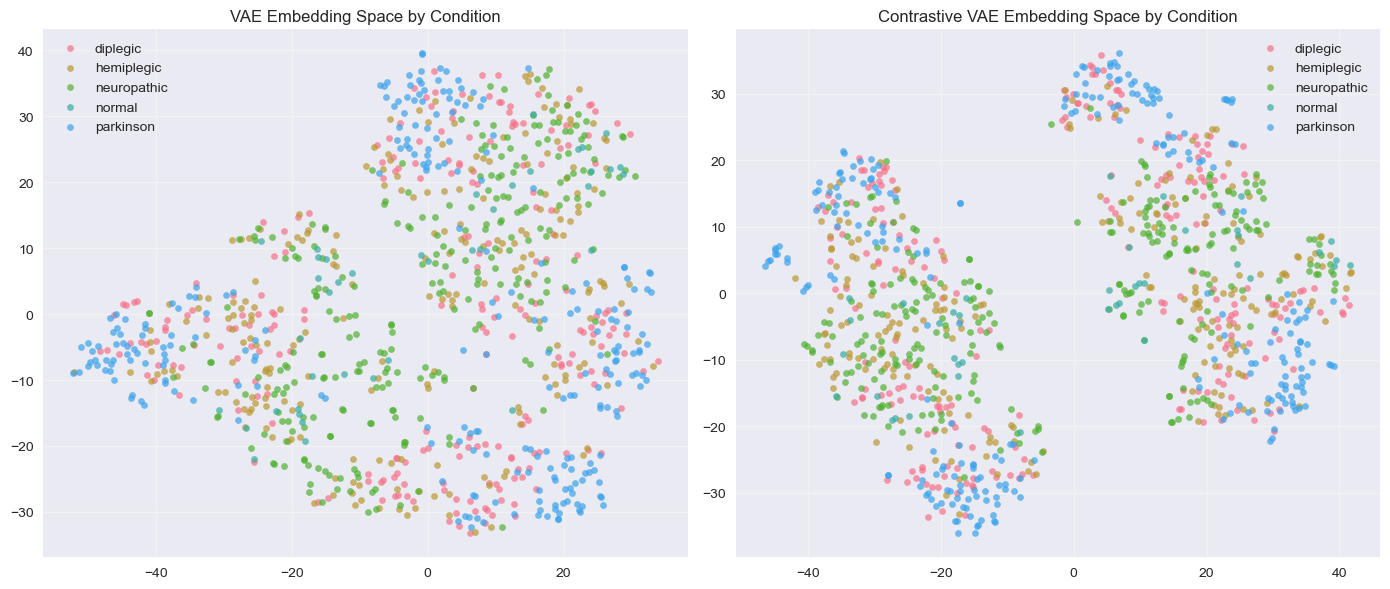

In [8]:
def tsne_2d(embeddings, n_components=2, n_pca=50, random_state=42):
    pca = PCA(n_components=min(n_pca, embeddings.shape[1]))
    emb_pca = pca.fit_transform(embeddings)
    tsne = TSNE(n_components=n_components, random_state=random_state, perplexity=min(30, len(embeddings)-1))
    return tsne.fit_transform(emb_pca)

print("Running t-SNE for VAE...")
emb_vae_2d = tsne_2d(embeddings_vae)

print("Running t-SNE for Contrastive VAE...")
emb_contrastive_2d = tsne_2d(embeddings_contrastive)

df_vae = pd.DataFrame({
    'x': emb_vae_2d[:,0],
    'y': emb_vae_2d[:,1],
    'condition': all_conditions
})
df_contrastive = pd.DataFrame({
    'x': emb_contrastive_2d[:,0],
    'y': emb_contrastive_2d[:,1],
    'condition': all_conditions
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for cond in sorted(set(all_conditions)):
    m = df_vae['condition'] == cond
    axes[0].scatter(df_vae.loc[m,'x'], df_vae.loc[m,'y'], label=cond, alpha=0.7, s=20)
axes[0].set_title('VAE Embedding Space by Condition')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for cond in sorted(set(all_conditions)):
    m = df_contrastive['condition'] == cond
    axes[1].scatter(df_contrastive.loc[m,'x'], df_contrastive.loc[m,'y'], label=cond, alpha=0.7, s=20)
axes[1].set_title('Contrastive VAE Embedding Space by Condition')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

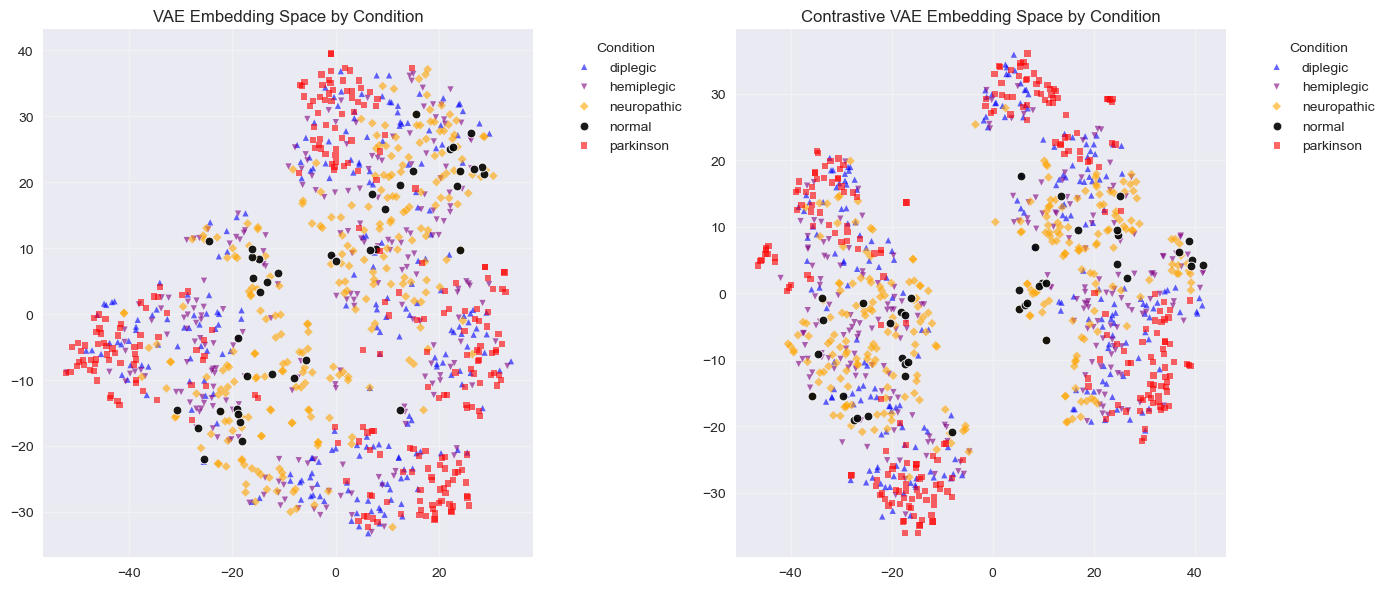

In [9]:
# Custom colors & markers – make 'normal' very distinct
unique_conditions = sorted(set(all_conditions))

color_map = {
    'normal': 'black',
    'parkinson': 'red',
    'neuropathic': 'orange',
    'diplegic': 'blue',
    'hemiplegic': 'purple',
}
marker_map = {
    'normal': 'o',        # circle
    'parkinson': 's',     # square
    'neuropathic': 'D',   # diamond
    'diplegic': '^',      # triangle
    'hemiplegic': 'v',    # triangle-down
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# VAE plot
for cond in unique_conditions:
    m = df_vae['condition'] == cond
    if m.sum() == 0:
        continue
    c = color_map.get(cond, 'gray')
    mk = marker_map.get(cond, 'o')
    size = 40 if cond == 'normal' else 20
    alpha = 0.9 if cond == 'normal' else 0.6
    edge = 'white' if cond == 'normal' else 'none'
    axes[0].scatter(
        df_vae.loc[m, 'x'], df_vae.loc[m, 'y'],
        label=cond,
        c=c,
        marker=mk,
        s=size,
        alpha=alpha,
        edgecolors=edge,
        linewidths=0.7 if cond == 'normal' else 0.0,
    )
axes[0].set_title('VAE Embedding Space by Condition')
axes[0].grid(True, alpha=0.3)
axes[0].legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')

# Contrastive VAE plot
for cond in unique_conditions:
    m = df_contrastive['condition'] == cond
    if m.sum() == 0:
        continue
    c = color_map.get(cond, 'gray')
    mk = marker_map.get(cond, 'o')
    size = 40 if cond == 'normal' else 20
    alpha = 0.9 if cond == 'normal' else 0.6
    edge = 'white' if cond == 'normal' else 'none'
    axes[1].scatter(
        df_contrastive.loc[m, 'x'], df_contrastive.loc[m, 'y'],
        label=cond,
        c=c,
        marker=mk,
        s=size,
        alpha=alpha,
        edgecolors=edge,
        linewidths=0.7 if cond == 'normal' else 0.0,
    )
axes[1].set_title('Contrastive VAE Embedding Space by Condition')
axes[1].grid(True, alpha=0.3)
axes[1].legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [18]:
def make_balanced_binary(embeddings, is_pathological, random_seed=42):
    rng = np.random.default_rng(random_seed)
    is_pathological = np.array(is_pathological)
    idx_healthy = np.where(is_pathological == 0)[0]
    idx_path = np.where(is_pathological == 1)[0]

    n_healthy = len(idx_healthy)
    n_path = len(idx_path)
    target = min(n_healthy, n_path)

    idx_h_sel = rng.choice(idx_healthy, size=target, replace=False)
    idx_p_sel = rng.choice(idx_path, size=target, replace=False)

    idx_bal = np.concatenate([idx_h_sel, idx_p_sel])
    rng.shuffle(idx_bal)

    X_bal = embeddings[idx_bal]
    y_bal = is_pathological[idx_bal]

    print("Binary balanced counts:",
          "healthy:", (y_bal==0).sum(),
          "pathology:", (y_bal==1).sum())
    return X_bal, y_bal

In [10]:
# Binary labels: healthy (normal) vs any pathology
is_pathological = (all_conditions != 'normal').astype(int)

def eval_binary_classifier(embeddings, y_bin, name='model'):
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, y_bin, test_size=0.2, random_state=42, stratify=y_bin
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    clf = LogisticRegression(max_iter=2000, class_weight='balanced')
    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_test_s)

    print(f"\n{name} - Binary Healthy vs Pathology")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=['healthy','pathological']))

print("== Binary Anomaly Detection ==")
eval_binary_classifier(embeddings_vae, is_pathological, name='VAE')
eval_binary_classifier(embeddings_contrastive, is_pathological, name='Contrastive VAE')

== Binary Anomaly Detection ==

VAE - Binary Healthy vs Pathology
Accuracy: 0.935
              precision    recall  f1-score   support

     healthy       0.27      0.38      0.32         8
pathological       0.97      0.96      0.97       192

    accuracy                           0.94       200
   macro avg       0.62      0.67      0.64       200
weighted avg       0.95      0.94      0.94       200


Contrastive VAE - Binary Healthy vs Pathology
Accuracy: 0.915
              precision    recall  f1-score   support

     healthy       0.20      0.38      0.26         8
pathological       0.97      0.94      0.95       192

    accuracy                           0.92       200
   macro avg       0.59      0.66      0.61       200
weighted avg       0.94      0.92      0.93       200



In [19]:
X_vae_bin, y_bin_vae = make_balanced_binary(embeddings_vae, is_pathological)
X_contr_bin, y_bin_contr = make_balanced_binary(embeddings_contrastive, is_pathological)

eval_binary_classifier(X_vae_bin, y_bin_vae, name='VAE (balanced)')
eval_binary_classifier(X_contr_bin, y_bin_contr, name='Contrastive (balanced)')

Binary balanced counts: healthy: 40 pathology: 40
Binary balanced counts: healthy: 40 pathology: 40

VAE (balanced) - Binary Healthy vs Pathology
Accuracy: 0.6875
              precision    recall  f1-score   support

     healthy       0.71      0.62      0.67         8
pathological       0.67      0.75      0.71         8

    accuracy                           0.69        16
   macro avg       0.69      0.69      0.69        16
weighted avg       0.69      0.69      0.69        16


Contrastive (balanced) - Binary Healthy vs Pathology
Accuracy: 0.875
              precision    recall  f1-score   support

     healthy       0.80      1.00      0.89         8
pathological       1.00      0.75      0.86         8

    accuracy                           0.88        16
   macro avg       0.90      0.88      0.87        16
weighted avg       0.90      0.88      0.87        16



In [11]:
# from imblearn.over_sampling import SMOTE

# def eval_binary_classifier_balanced(embeddings, y_bin, name='model'):
#     X_train, X_test, y_train, y_test = train_test_split(
#         embeddings, y_bin, test_size=0.2, random_state=42, stratify=y_bin
#     )
    
#     # Oversample minority class (healthy)
#     sm = SMOTE()
#     X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

#     scaler = StandardScaler()
#     X_train_s = scaler.fit_transform(X_train_res)
#     X_test_s = scaler.transform(X_test)

#     clf = LogisticRegression(max_iter=2000)
#     clf.fit(X_train_s, y_train_res)
#     y_pred = clf.predict(X_test_s)

#     print(f"\n{name} (SMOTE Oversampled) - Binary Healthy vs Pathology")
#     print("Accuracy:", accuracy_score(y_test, y_pred))
#     print(classification_report(y_test, y_pred, target_names=['healthy','pathological']))


In [13]:
import numpy as np
from collections import defaultdict

def make_balanced_by_condition(embeddings, conditions, max_per_class=None, random_seed=42):
    """
    Return balanced embeddings/conditions with (roughly) equal samples per condition.

    embeddings: np.array (N, D)
    conditions: np.array (N,) of strings: 'normal', 'parkinson', ...
    max_per_class: cap per class; if None, use min class size
    """
    rng = np.random.default_rng(random_seed)
    conditions = np.array(conditions)
    n = len(conditions)

    # group indices by condition
    idx_by_cond = defaultdict(list)
    for i, c in enumerate(conditions):
        idx_by_cond[c].append(i)

    # how many per class?
    class_counts = {c: len(idx) for c, idx in idx_by_cond.items()}
    print("Class counts before balancing:", class_counts)

    if max_per_class is None:
        target = min(class_counts.values())  # strict balance
    else:
        target = min(max_per_class, min(class_counts.values()))

    balanced_indices = []
    for c, idxs in idx_by_cond.items():
        if len(idxs) > target:
            chosen = rng.choice(idxs, size=target, replace=False)
        else:
            chosen = np.array(idxs)  # already <= target
        balanced_indices.append(chosen)

    balanced_indices = np.concatenate(balanced_indices)
    rng.shuffle(balanced_indices)

    emb_bal = embeddings[balanced_indices]
    cond_bal = conditions[balanced_indices]

    print("Balanced total samples:", len(cond_bal))
    print("Balanced class counts:", {c: (cond_bal == c).sum() for c in sorted(set(cond_bal))})
    return emb_bal, cond_bal

In [12]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

def oversample_minority(X, y):
    # Identify minority and majority classes
    minority_class = y == 0       # healthy
    majority_class = y == 1       # pathological

    X_min = X[minority_class]
    y_min = y[minority_class]

    X_maj = X[majority_class]
    y_maj = y[majority_class]

    # Randomly duplicate minority samples until sizes match
    n_to_add = len(X_maj) - len(X_min)
    idx = np.random.randint(0, len(X_min), size=n_to_add)

    X_res = np.vstack([X, X_min[idx]])
    y_res = np.hstack([y, y_min[idx]])

    return X_res, y_res


def eval_binary_classifier_manual_oversample(embeddings, y_bin, name='model'):
    # Split first
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, y_bin, test_size=0.2, random_state=42, stratify=y_bin
    )

    # Manual oversampling
    X_train_res, y_train_res = oversample_minority(X_train, y_train)

    # Scale
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_res)
    X_test_s = scaler.transform(X_test)

    # Train classifier
    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_train_s, y_train_res)

    y_pred = clf.predict(X_test_s)

    print(f"\n{name} - Balanced by Manual Oversampling")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=['healthy', 'pathological']))


In [14]:
embeddings_vae_bal, conditions_bal = make_balanced_by_condition(embeddings_vae, all_conditions)
embeddings_contr_bal, conditions_contr_bal = make_balanced_by_condition(embeddings_contrastive, all_conditions)

Class counts before balancing: {'parkinson': 249, 'diplegic': 228, 'hemiplegic': 223, 'neuropathic': 260, 'normal': 40}
Balanced total samples: 200
Balanced class counts: {'diplegic': 40, 'hemiplegic': 40, 'neuropathic': 40, 'normal': 40, 'parkinson': 40}
Class counts before balancing: {'parkinson': 249, 'diplegic': 228, 'hemiplegic': 223, 'neuropathic': 260, 'normal': 40}
Balanced total samples: 200
Balanced class counts: {'diplegic': 40, 'hemiplegic': 40, 'neuropathic': 40, 'normal': 40, 'parkinson': 40}


In [16]:
# def undersample_majority(X, y):
#     # Majority (pathological)
#     maj_idx = np.where(y == 1)[0]
#     min_idx = np.where(y == 0)[0]

#     # Randomly choose a subset equal to minority size
#     chosen_maj = np.random.choice(maj_idx, size=len(min_idx), replace=False)

#     # Combine indices
#     final_idx = np.hstack([min_idx, chosen_maj])

#     return X[final_idx], y[final_idx]


In [15]:
# X_train_bal, y_train_bal = undersample_majority(X_train, y_train)

# clf = LogisticRegression(
#     max_iter=2000,
#     class_weight='balanced'
# )
# clf.fit(X_train_bal, y_train_bal)


In [17]:
# Multi-class: normal, parkinson, neuropathy, etc.
le_cond = LabelEncoder()
y_cond = le_cond.fit_transform(all_conditions)
cond_names = le_cond.classes_
print("Condition classes:", cond_names)

def eval_multiclass_classifier(embeddings, y, name='model'):
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, y, test_size=0.2, random_state=42, stratify=y
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    clf = LogisticRegression(max_iter=3000, multi_class='multinomial')
    clf.fit(X_train_s, y_train)
    y_pred = clf.predict(X_test_s)

    print(f"\n{name} - Multi-class Condition Classification")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=cond_names))

print("== Multi-class Condition Classification ==")
eval_multiclass_classifier(embeddings_vae, y_cond, name='VAE')
eval_multiclass_classifier(embeddings_contrastive, y_cond, name='Contrastive VAE')

Condition classes: ['diplegic' 'hemiplegic' 'neuropathic' 'normal' 'parkinson']
== Multi-class Condition Classification ==

VAE - Multi-class Condition Classification
Accuracy: 0.49
              precision    recall  f1-score   support

    diplegic       0.39      0.41      0.40        46
  hemiplegic       0.38      0.41      0.39        44
 neuropathic       0.59      0.56      0.57        52
      normal       0.29      0.25      0.27         8
   parkinson       0.64      0.60      0.62        50

    accuracy                           0.49       200
   macro avg       0.46      0.45      0.45       200
weighted avg       0.50      0.49      0.49       200


Contrastive VAE - Multi-class Condition Classification
Accuracy: 0.52
              precision    recall  f1-score   support

    diplegic       0.42      0.43      0.43        46
  hemiplegic       0.35      0.34      0.34        44
 neuropathic       0.60      0.62      0.61        52
      normal       0.17      0.12      0.

## Summary

- Compared healthy vs pathological gaits in VAE and Contrastive VAE embedding spaces.
- Visualized condition clusters with t-SNE.
- Evaluated:
  - Binary anomaly detection (healthy vs any pathology).
  - Multi-class classification (normal, Parkinson, neuropathy, etc.).
- Next steps:
  - Tune condition labels / folder mapping for Parkinson dataset.
  - Try projection-head embeddings (`use_projection=True`) for contrastive model.
  - Explore per-view or per-sequence effects if that metadata is available.